In [1]:
# =============================================
# COLAB SETUP — Run this cell FIRST
# =============================================
import os
if not os.path.exists("/content/project"):
    !unzip -q /content/project1-policyclaim-llm.zip -d /content/
    !mv /content/repo2 /content/project
    print("Project unzipped!")
else:
    print("Project already exists, skipping unzip.")

os.chdir("/content/project/notebooks")
print(f"Working directory: {os.getcwd()}")
!pip install pandas matplotlib seaborn -q
print("Ready!")

Project unzipped!
Working directory: /content/project/notebooks
Ready!


In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

# Load train and test
train_data = [json.loads(line) for line in open("../data/train.jsonl")]
test_data = [json.loads(line) for line in open("../data/test.jsonl")]

def messages_to_df(data, split_name):
    rows = []
    for item in data:
        msgs = item["messages"]
        rows.append({
            "claim": msgs[1]["content"],
            "label": msgs[2]["content"],
            "split": split_name
        })
    return pd.DataFrame(rows)

train_df = messages_to_df(train_data, "train")
test_df = messages_to_df(test_data, "test")
full_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total claims: {len(full_df)}")
print(f"  Train: {len(train_df)}")
print(f"  Test:  {len(test_df)}")
print(f"\nLabel distribution:")
print(full_df["label"].value_counts())

Total claims: 193
  Train: 143
  Test:  50

Label distribution:
label
Regulation        46
Strategy          41
Inclusion         37
Infrastructure    36
Capacity          33
Name: count, dtype: int64


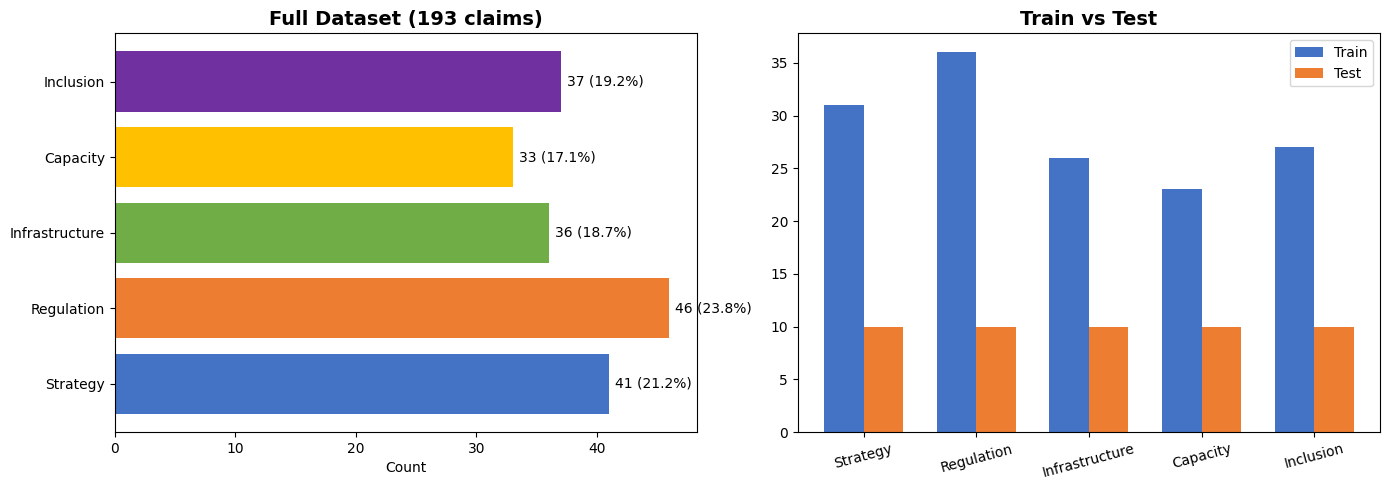

In [3]:
labels = ["Strategy", "Regulation", "Infrastructure", "Capacity", "Inclusion"]
colors = ["#4472C4", "#ED7D31", "#70AD47", "#FFC000", "#7030A0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full dataset
counts = full_df["label"].value_counts().reindex(labels)
axes[0].barh(labels, counts.values, color=colors)
axes[0].set_title("Full Dataset (193 claims)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(v + 0.5, i, f"{v} ({v/len(full_df)*100:.1f}%)", va="center")

# Train vs Test
train_c = train_df["label"].value_counts().reindex(labels)
test_c = test_df["label"].value_counts().reindex(labels)
x = range(len(labels))
w = 0.35
axes[1].bar([i-w/2 for i in x], train_c.values, w, label="Train", color="#4472C4")
axes[1].bar([i+w/2 for i in x], test_c.values, w, label="Test", color="#ED7D31")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_title("Train vs Test", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
for label in labels:
    print(f"\n{'='*70}")
    print(f"  {label.upper()}")
    print(f"{'='*70}")
    examples = full_df[full_df["label"] == label]["claim"].head(3).tolist()
    for i, ex in enumerate(examples, 1):
        print(f"  {i}. {ex}")


  STRATEGY
  1. Countries should develop national AI strategies to coordinate government efforts across ministries.
  2. Over 70 countries have already published AI policies or national strategies as of 2024.
  3. National AI strategies should prioritize both the promotion of AI innovation and the mitigation of associated risks.

  REGULATION
  1. Transparency and accountability requirements should be embedded in regulatory frameworks governing public-sector AI use.
  2. Intellectual property frameworks need revision to balance AI-driven innovation with the rights of content creators.
  3. Competition authorities in several OECD countries have begun monitoring AI markets for excessive concentration.

  INFRASTRUCTURE
  1. Broadband connectivity expansion is essential for enabling widespread AI adoption across all regions.
  2. Several OECD countries have established national AI testbed facilities to support research and experimentation.
  3. Shared computing resources funded by govern

In [5]:
print("Example training sample:")
print("=" * 60)
print(json.dumps(train_data[0], indent=2))

Example training sample:
{
  "messages": [
    {
      "role": "system",
      "content": "Classify the following policy claim into exactly one category: Strategy, Regulation, Infrastructure, Capacity, or Inclusion."
    },
    {
      "role": "user",
      "content": "Countries should develop national AI strategies to coordinate government efforts across ministries."
    },
    {
      "role": "assistant",
      "content": "Strategy"
    }
  ]
}


In [10]:
# =============================================
# COLAB SETUP — Run this cell FIRST
# =============================================
import os
if not os.path.exists("/content/project"):
    !unzip -q /content/project1-policyclaim-llm.zip -d /content/
    !mv /content/repo2 /content/project
    print("Project unzipped!")
else:
    print("Project already exists, skipping unzip.")

os.chdir("/content/project/notebooks")
print(f"Working directory: {os.getcwd()}")

# Install Unsloth and its dependencies, including unsloth_zoo
!pip install "unsloth[colab-new]" --upgrade -q
!pip install unsloth_zoo -q
!pip install scikit-learn seaborn -q

print("\nAll packages installed!")

Project already exists, skipping unzip.
Working directory: /content/project/notebooks

All packages installed!


In [3]:
import os
# 작업 디렉토리 재설정
os.chdir("/content/project/notebooks")
print(f"현재 작업 디렉토리: {os.getcwd()}")

from unsloth import FastLanguageModel
import torch, json

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 256,
    load_in_4bit = True,
    dtype = None,
)
FastLanguageModel.for_inference(model)

test_data = [json.loads(line) for line in open("../data/test.jsonl")]
test_claims = [item["messages"][1]["content"] for item in test_data]
gold_labels = [item["messages"][2]["content"] for item in test_data]
SYSTEM_PROMPT = test_data[0]["messages"][0]["content"]

print("Model loaded!")
print(f"Test samples: {len(test_claims)}")

현재 작업 디렉토리: /content/project/notebooks
==((====))==  Unsloth 2026.3.5: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-instruct-bnb-4bit as a legacy tokenizer.


Model loaded!
Test samples: 50


In [4]:
import os
print(f"현재 작업 디렉토리: {os.getcwd()}")
print("현재 디렉토리 파일 목록:", os.listdir("."))
if os.path.exists("../data"):
    print("../data 디렉토리 파일 목록:", os.listdir("../data"))
else:
    print("../data 디렉토리가 존재하지 않습니다.")

현재 작업 디렉토리: /content/project/notebooks
현재 디렉토리 파일 목록: ['unsloth_compiled_cache', '01_data_building.ipynb', 'huggingface_tokenizers_cache', '03_finetune_qlora.ipynb', '04_evaluation.ipynb', '02_baseline_eval.ipynb']
../data 디렉토리 파일 목록: ['README.md', 'sources.csv', 'train.jsonl', 'test.jsonl']


In [12]:
VALID_LABELS = ["Strategy", "Regulation", "Infrastructure", "Capacity", "Inclusion"]

# Standard tokenizer settings
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

def predict(claim):
    prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n{SYSTEM_PROMPT}<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{claim}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            use_cache=False, # Disable cache to fix broadcast shape mismatch bug
            temperature=0.01,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True).strip()

    for label in VALID_LABELS:
        if label.lower() in response.lower():
            return label
    return "INVALID"

print("Running zero-shot predictions with cache disabled (stability mode)...")
baseline_preds = []
for i, claim in enumerate(test_claims):
    try:
        pred = predict(claim)
        baseline_preds.append(pred)
    except Exception as e:
        baseline_preds.append("ERROR")
        if i == 0:
             print(f"  Persistent error at index {i}: {e}")

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{len(test_claims)}] done")

print(f"All {len(test_claims)} predictions complete!")

Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running zero-shot predictions with cache disabled (stability mode)...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1

  [10/50] done


Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  [30/50] done


Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [40/50] done


Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [50/50] done
All 50 predictions complete!


In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd, numpy as np

n_invalid = sum(1 for p in baseline_preds if p == "INVALID")
invalid_rate = n_invalid / len(baseline_preds) * 100

valid_mask = [p != "INVALID" for p in baseline_preds]
valid_golds = [g for g, v in zip(gold_labels, valid_mask) if v]
valid_preds = [p for p, v in zip(baseline_preds, valid_mask) if v]

accuracy = accuracy_score(valid_golds, valid_preds) if valid_preds else 0
macro_f1 = f1_score(valid_golds, valid_preds, average="macro", labels=VALID_LABELS, zero_division=0) if valid_preds else 0

print(f"Accuracy:     {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Macro F1:     {macro_f1:.3f}")
print(f"Invalid Rate: {invalid_rate:.1f}% ({n_invalid}/{len(baseline_preds)})")
print()
if valid_preds:
    print(classification_report(valid_golds, valid_preds, labels=VALID_LABELS, zero_division=0))

Accuracy:     0.837 (83.7%)
Macro F1:     0.838
Invalid Rate: 14.0% (7/50)

                precision    recall  f1-score   support

      Strategy       0.60      0.75      0.67         8
    Regulation       0.90      1.00      0.95         9
Infrastructure       0.86      0.67      0.75         9
      Capacity       0.88      0.78      0.82         9
     Inclusion       1.00      1.00      1.00         8

      accuracy                           0.84        43
     macro avg       0.85      0.84      0.84        43
  weighted avg       0.85      0.84      0.84        43



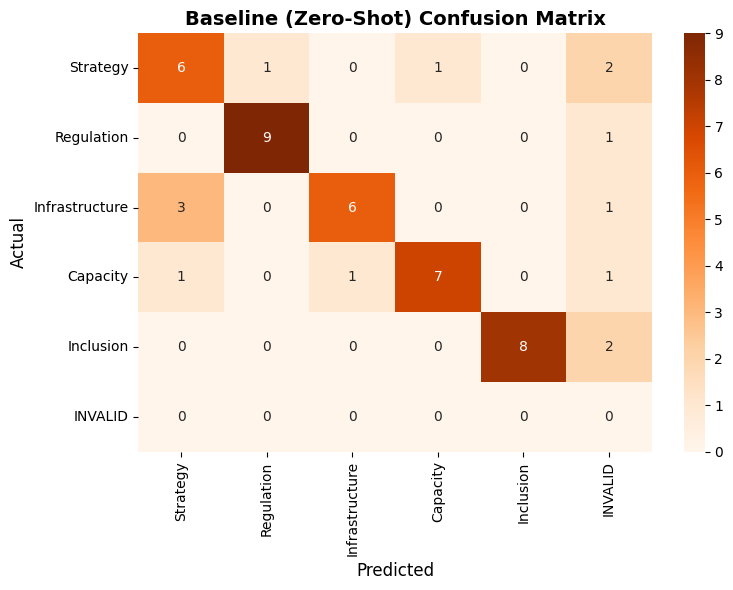

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results", exist_ok=True)

all_labels = VALID_LABELS + (["INVALID"] if n_invalid > 0 else [])
cm = confusion_matrix(gold_labels, baseline_preds, labels=all_labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=all_labels, yticklabels=all_labels, ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Baseline (Zero-Shot) Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/confusion_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
baseline_metrics = {
    "model": "Llama-3.1-8B-Instruct",
    "method": "zero-shot",
    "accuracy": round(accuracy, 4),
    "macro_f1": round(macro_f1, 4),
    "invalid_rate": round(invalid_rate, 2),
    "n_test": len(test_claims),
    "n_invalid": n_invalid,
}
with open("../results/baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

pred_df = pd.DataFrame({
    "claim": test_claims,
    "gold_label": gold_labels,
    "baseline_pred": baseline_preds,
})
pred_df.to_csv("../results/predictions.csv", index=False)

print("Saved: results/baseline_metrics.json")
print("Saved: results/predictions.csv")
print()
for k, v in baseline_metrics.items():
    print(f"  {k}: {v}")

Saved: results/baseline_metrics.json
Saved: results/predictions.csv

  model: Llama-3.1-8B-Instruct
  method: zero-shot
  accuracy: 0.8372
  macro_f1: 0.8375
  invalid_rate: 14.0
  n_test: 50
  n_invalid: 7


In [16]:
# =============================================
# COLAB SETUP — Run this cell FIRST
# =============================================
import os
if not os.path.exists("/content/project"):
    !unzip -q /content/project1-policyclaim-llm.zip -d /content/
    !mv /content/repo2 /content/project
    print("Project unzipped!")
else:
    print("Project already exists, skipping unzip.")

os.chdir("/content/project/notebooks")
print(f"Working directory: {os.getcwd()}")

!pip install pyarrow==17.0.0 -q
!pip install --no-deps unsloth -q
!pip install --no-deps trl peft accelerate bitsandbytes xformers -q
!pip install scikit-learn seaborn -q

print("\nAll packages installed!")

Project already exists, skipping unzip.
Working directory: /content/project/notebooks
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.3.0 requires pyarrow>=21.0.0, but you have pyarrow 17.0.0 which is incompatible.

All packages installed!


In [17]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 256,
    load_in_4bit = True,
    dtype = None,
)
print("Base model loaded!")

==((====))==  Unsloth 2026.3.5: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-instruct-bnb-4bit as a legacy tokenizer.


Base model loaded!


In [18]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 32,
    lora_dropout = 0.05,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.3.5 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable: 41,943,040 / 4,582,543,360 (0.92%)


In [19]:
from datasets import Dataset
import json

train_data = [json.loads(line) for line in open("../data/train.jsonl")]

def format_chat(example):
    text = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False,
    )
    return {"text": text}

train_dataset = Dataset.from_list(train_data)
train_dataset = train_dataset.map(format_chat)

print(f"Training samples: {len(train_dataset)}")
print(f"\nExample (first 300 chars):")
print(train_dataset[0]["text"][:300])

Map:   0%|          | 0/143 [00:00<?, ? examples/s]

Training samples: 143

Example (first 300 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

Classify the following policy claim into exactly one category: Strategy, Regulation, Infrastructure, Capacity, or Inclusion.<|eot_id|><|start_header_id|>user<|end_header_id|>




In [20]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = 256,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        num_train_epochs = 3,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        learning_rate = 2e-4,
        warmup_steps = 10,
        lr_scheduler_type = "cosine",
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        optim = "adamw_8bit",
        logging_steps = 5,
        weight_decay = 0.01,
        seed = 42,
        output_dir = "./outputs",
    ),
)

print("Starting training...")
trainer_stats = trainer.train()

print(f"\nTraining complete!")
print(f"  Steps: {trainer_stats.global_step}")
print(f"  Loss:  {trainer_stats.training_loss:.4f}")
print(f"  Time:  {trainer_stats.metrics['train_runtime']:.0f}s")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/143 [00:00<?, ? examples/s]

Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 143 | Num Epochs = 3 | Total steps = 54
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss
5,3.917719
10,1.913504
15,0.902396
20,0.807584
25,0.637177
30,0.562429
35,0.539545
40,0.483774
45,0.403688
50,0.449249



Training complete!
  Steps: 54
  Loss:  1.0117
  Time:  212s


In [22]:
ADAPTER_PATH = "../adapter"
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

print(f"Adapter saved to: {ADAPTER_PATH}")
import os
for f in os.listdir(ADAPTER_PATH):
    size = os.path.getsize(os.path.join(ADAPTER_PATH, f))
    print(f"  {f} ({size/1024:.0f} KB)")

Adapter saved to: ../adapter
  README.md (5 KB)
  chat_template.jinja (5 KB)
  adapter_model.safetensors (163899 KB)
  tokenizer.json (16807 KB)
  tokenizer_config.json (0 KB)
  adapter_config.json (1 KB)


In [26]:
FastLanguageModel.for_inference(model)

examples = [
    "Countries should develop national AI strategies.",
    "AI systems posing unacceptable risks must be prohibited.",
    "5G coverage reached 57 percent of the global population.",
    "Education systems must be reformed for AI economies.",
    "Women account for only one-third of ChatGPT users.",
]

SYSTEM_PROMPT = "Classify the following policy claim into exactly one category: Strategy, Regulation, Infrastructure, Capacity, or Inclusion."

print("Sanity check:")
print("=" * 60)
for claim in examples:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": claim},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=10,
            temperature=0.01,
            do_sample=True,
            use_cache=False  # Added to fix broadcast shape mismatch bug
        )
    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True).strip()
    print(f"  {claim[:55]}...")
    print(f"  → {response}\n")

Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sanity check:


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Countries should develop national AI strategies....
  → Strategy



Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  AI systems posing unacceptable risks must be prohibited...
  → Regulation



Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  5G coverage reached 57 percent of the global population...
  → Infrastructure



Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Education systems must be reformed for AI economies....
  → Capacity

  Women account for only one-third of ChatGPT users....
  → Inclusion



In [27]:
# =============================================
# COLAB SETUP — Run this cell FIRST
# =============================================
import os
if not os.path.exists("/content/project"):
    !unzip -q /content/project1-policyclaim-llm.zip -d /content/
    !mv /content/repo2 /content/project
    print("Project unzipped!")
else:
    print("Project already exists, skipping unzip.")

os.chdir("/content/project/notebooks")
print(f"Working directory: {os.getcwd()}")

!pip install pyarrow==17.0.0 -q
!pip install --no-deps unsloth -q
!pip install --no-deps trl peft accelerate bitsandbytes xformers -q
!pip install scikit-learn seaborn -q

print("\nAll packages installed!")

Project already exists, skipping unzip.
Working directory: /content/project/notebooks

All packages installed!


In [28]:
from unsloth import FastLanguageModel
import torch, json

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "../adapter",
    max_seq_length = 256,
    load_in_4bit = True,
    dtype = None,
)
FastLanguageModel.for_inference(model)
print("Fine-tuned model loaded!")

==((====))==  Unsloth 2026.3.5: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-instruct-bnb-4bit as a legacy tokenizer.


Fine-tuned model loaded!


In [30]:
import pandas as pd

test_data = [json.loads(line) for line in open("../data/test.jsonl")]
test_claims = [item["messages"][1]["content"] for item in test_data]
gold_labels = [item["messages"][2]["content"] for item in test_data]
SYSTEM_PROMPT = test_data[0]["messages"][0]["content"]
VALID_LABELS = ["Strategy", "Regulation", "Infrastructure", "Capacity", "Inclusion"]

def predict(claim):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": claim},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=10,
            temperature=0.01,
            do_sample=True,
            use_cache=False # Added to fix broadcast shape mismatch bug
        )
    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True).strip()
    for label in VALID_LABELS:
        if label.lower() in response.lower():
            return label
    return "INVALID"

print("Running predictions...")
finetuned_preds = []
for i, claim in enumerate(test_claims):
    pred = predict(claim)
    finetuned_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{len(test_claims)}] done")
print("Complete!")

Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running predictions...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1

  [10/50] done


Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  [30/50] done


Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [40/50] done


Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [50/50] done
Complete!


In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

n_invalid = sum(1 for p in finetuned_preds if p == "INVALID")
invalid_rate = n_invalid / len(finetuned_preds) * 100

valid_mask = [p != "INVALID" for p in finetuned_preds]
valid_golds = [g for g, v in zip(gold_labels, valid_mask) if v]
valid_preds = [p for p, v in zip(finetuned_preds, valid_mask) if v]

accuracy = accuracy_score(valid_golds, valid_preds) if valid_preds else 0
macro_f1 = f1_score(valid_golds, valid_preds, average="macro", labels=VALID_LABELS, zero_division=0) if valid_preds else 0

print(f"Accuracy:     {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Macro F1:     {macro_f1:.3f}")
print(f"Invalid Rate: {invalid_rate:.1f}%")
print()
if valid_preds:
    print(classification_report(valid_golds, valid_preds, labels=VALID_LABELS, zero_division=0))

Accuracy:     0.940 (94.0%)
Macro F1:     0.941
Invalid Rate: 0.0%

                precision    recall  f1-score   support

      Strategy       1.00      0.90      0.95        10
    Regulation       0.91      1.00      0.95        10
Infrastructure       0.83      1.00      0.91        10
      Capacity       1.00      0.90      0.95        10
     Inclusion       1.00      0.90      0.95        10

      accuracy                           0.94        50
     macro avg       0.95      0.94      0.94        50
  weighted avg       0.95      0.94      0.94        50



In [32]:
with open("../results/baseline_metrics.json") as f:
    baseline = json.load(f)

print("=" * 60)
print("  BASELINE vs FINE-TUNED")
print("=" * 60)
print(f"  {'Metric':<15} {'Baseline':>10} {'Fine-Tuned':>12} {'Change':>10}")
print("  " + "-" * 47)
print(f"  {'Accuracy':<15} {baseline['accuracy']:>10.3f} {accuracy:>12.3f} {'+' if accuracy > baseline['accuracy'] else ''}{(accuracy-baseline['accuracy'])*100:>8.1f}%p")
print(f"  {'Macro F1':<15} {baseline['macro_f1']:>10.3f} {macro_f1:>12.3f} {'+' if macro_f1 > baseline['macro_f1'] else ''}{macro_f1-baseline['macro_f1']:>8.3f}")
print(f"  {'Invalid Rate':<15} {baseline['invalid_rate']:>9.1f}% {invalid_rate:>11.1f}% {invalid_rate-baseline['invalid_rate']:>8.1f}%p")
print("=" * 60)

  BASELINE vs FINE-TUNED
  Metric            Baseline   Fine-Tuned     Change
  -----------------------------------------------
  Accuracy             0.837        0.940 +    10.3%p
  Macro F1             0.838        0.941 +   0.103
  Invalid Rate         14.0%         0.0%    -14.0%p


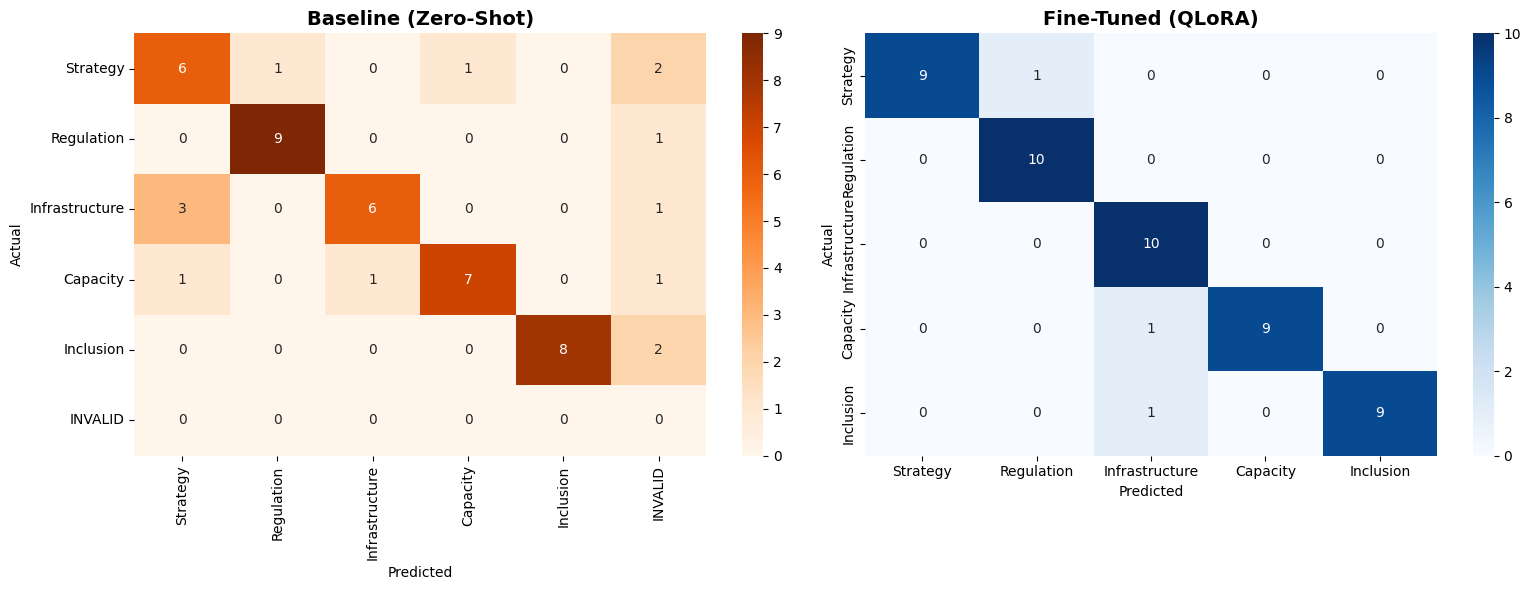

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

pred_df = pd.read_csv("../results/predictions.csv")
baseline_preds_loaded = pred_df["baseline_pred"].tolist()

all_labels_b = VALID_LABELS + (["INVALID"] if baseline["n_invalid"] > 0 else [])
all_labels_f = VALID_LABELS + (["INVALID"] if n_invalid > 0 else [])

cm_b = confusion_matrix(gold_labels, baseline_preds_loaded, labels=all_labels_b)
cm_f = confusion_matrix(gold_labels, finetuned_preds, labels=all_labels_f)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_b, annot=True, fmt="d", cmap="Oranges",
            xticklabels=all_labels_b, yticklabels=all_labels_b, ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Baseline (Zero-Shot)", fontsize=14, fontweight="bold")

sns.heatmap(cm_f, annot=True, fmt="d", cmap="Blues",
            xticklabels=all_labels_f, yticklabels=all_labels_f, ax=axes[1])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Fine-Tuned (QLoRA)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

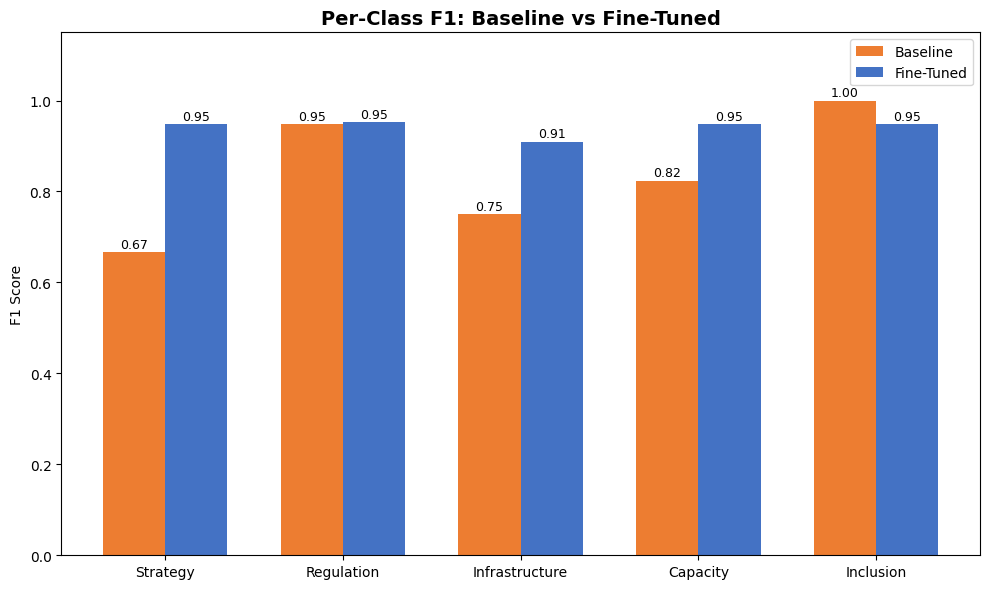


Per-Class F1:
  Category           Baseline   Fine-Tuned        Δ
  ------------------------------------------------
  Strategy              0.667        0.947   +0.281
  Regulation            0.947        0.952   +0.005
  Infrastructure        0.750        0.909   +0.159
  Capacity              0.824        0.947   +0.124
  Inclusion             1.000        0.947   -0.053


In [34]:
from sklearn.metrics import f1_score as calc_f1

b_valid_mask = [p != "INVALID" for p in baseline_preds_loaded]
b_golds = [g for g, v in zip(gold_labels, b_valid_mask) if v]
b_preds = [p for p, v in zip(baseline_preds_loaded, b_valid_mask) if v]

baseline_f1s, finetuned_f1s = [], []
for label in VALID_LABELS:
    bf = calc_f1([1 if g==label else 0 for g in b_golds],
                 [1 if p==label else 0 for p in b_preds], zero_division=0)
    ff = calc_f1([1 if g==label else 0 for g in valid_golds],
                 [1 if p==label else 0 for p in valid_preds], zero_division=0)
    baseline_f1s.append(bf)
    finetuned_f1s.append(ff)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(VALID_LABELS))
w = 0.35
bars1 = ax.bar([i-w/2 for i in x], baseline_f1s, w, label="Baseline", color="#ED7D31")
bars2 = ax.bar([i+w/2 for i in x], finetuned_f1s, w, label="Fine-Tuned", color="#4472C4")

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.2f}", ha="center", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(VALID_LABELS)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-Class F1: Baseline vs Fine-Tuned", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../results/per_class_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPer-Class F1:")
print(f"  {'Category':<16} {'Baseline':>10} {'Fine-Tuned':>12} {'Δ':>8}")
print("  " + "-" * 48)
for i, label in enumerate(VALID_LABELS):
    d = finetuned_f1s[i] - baseline_f1s[i]
    print(f"  {label:<16} {baseline_f1s[i]:>10.3f} {finetuned_f1s[i]:>12.3f} {d:>+8.3f}")

In [35]:
pred_df["finetuned_pred"] = finetuned_preds
pred_df["baseline_correct"] = pred_df["gold_label"] == pred_df["baseline_pred"]
pred_df["finetuned_correct"] = pred_df["gold_label"] == pred_df["finetuned_pred"]
pred_df.to_csv("../results/predictions.csv", index=False)

errors = pred_df[~pred_df["finetuned_correct"]]
print(f"Errors: {len(errors)}/{len(pred_df)}")
if len(errors) > 0:
    print("\nMisclassified:")
    for _, row in errors.iterrows():
        print(f"  Claim: {row['claim'][:75]}...")
        print(f"  Gold: {row['gold_label']}  Pred: {row['finetuned_pred']}\n")

fixed = pred_df[~pred_df["baseline_correct"] & pred_df["finetuned_correct"]]
broken = pred_df[pred_df["baseline_correct"] & ~pred_df["finetuned_correct"]]
print(f"Fixed by fine-tuning: {len(fixed)}")
print(f"Broken by fine-tuning: {len(broken)}")

Errors: 3/50

Misclassified:
  Claim: Low-income countries face disproportionate barriers in accessing AI technol...
  Gold: Inclusion  Pred: Infrastructure

  Claim: Dedicated digital government units staffed with skilled technology professi...
  Gold: Capacity  Pred: Infrastructure

  Claim: No single regulatory model works in isolation; effective AI governance requ...
  Gold: Strategy  Pred: Regulation

Fixed by fine-tuning: 12
Broken by fine-tuning: 1


In [36]:
finetuned_metrics = {
    "model": "Llama-3.1-8B-Instruct + QLoRA",
    "method": "SFT + QLoRA (rank 16, alpha 32, 3 epochs)",
    "accuracy": round(accuracy, 4),
    "macro_f1": round(macro_f1, 4),
    "invalid_rate": round(invalid_rate, 2),
    "n_test": len(test_claims),
    "n_invalid": n_invalid,
    "per_class_f1": {label: round(f, 4) for label, f in zip(VALID_LABELS, finetuned_f1s)},
}
with open("../results/finetuned_metrics.json", "w") as f:
    json.dump(finetuned_metrics, f, indent=2)

print("All results saved!")
for f in sorted(os.listdir("../results")):
    print(f"  results/{f}")

All results saved!
  results/.gitkeep
  results/baseline_metrics.json
  results/confusion_baseline.png
  results/confusion_comparison.png
  results/dataset_distribution.png
  results/finetuned_metrics.json
  results/per_class_f1_comparison.png
  results/predictions.csv
